In [1]:
from database.adatabase import ADatabase
import pandas as pd
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
from datetime import datetime, timedelta, timezone
from xgboost import XGBRegressor
import random

In [2]:
db = ADatabase("algo")
market = ADatabase("market")
market.connect()
russell1000 = market.retrieve("russell1000")
market.disconnect()

In [3]:
tickers = russell1000["ticker"].values
training_year = datetime.now().year - 3
holding_period = 5
today = datetime.now()
weekday = today.weekday() - 1 if today.weekday() != 0 else 4

In [39]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))[["date","week","month","weekday","ticker","adjclose"]]
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices["coefficient_of_variance"] = ticker_prices["adjclose"].rolling(100).std() / ticker_prices["adjclose"].rolling(100).mean()
        ticker_prices["buy_price"] = ticker_prices["adjclose"].shift(-1)
        ticker_prices["buy_date"] = ticker_prices["date"].shift(-1)
        ticker_prices["sell_price"] = ticker_prices["adjclose"].shift(-holding_period)
        ticker_prices["sell_date"] = ticker_prices["date"] + timedelta(days=holding_period/5*7)
        ticker_prices["return"] = (ticker_prices["sell_price"] - ticker_prices["buy_price"]) / ticker_prices ["buy_price"]
        prices.append(ticker_prices.iloc[100:])
    except Exception as e:
        print(ticker,str(e))
        continue
market.disconnect()
sim = pd.concat(prices).reset_index(drop=True)

model_prep: 100%|██████████| 1009/1009 [01:02<00:00, 16.08it/s]


In [40]:
positions = 10
hedge_percentage = 0.03
sim["weight"] = (1/positions)
sim["return"] = sim["return"] * sim["weight"]
sim["hedged_return"] = [max(float(-hedge_percentage/positions),x) for x in sim["return"]]
sim["month"] = [x.month for x in sim["date"]]
sim.sort_values("date",inplace=True)
trades = sim[sim["weekday"]==4].copy()
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades = processor.column_date_processing(trades)
market.connect()
benchmark = processor.column_date_processing(market.query("prices",{"ticker":"AMZN"}))[["date","adjclose"]]
market.disconnect()

In [41]:
a = pd.DataFrame(analysis).sort_values("lower_bound",ascending=False)
a

,vm,asc,skew,kurtosis,cr,std,coefficient_of_variance,return_to_std,treynor,lower_bound,winrate,average_win
1,coefficient_of_variance,False,0.158016,3.332058,1.018183,0.009750,0.009576,104.428759,2751.557476,0.987366,0.497590,0.003228
0,coefficient_of_variance,True,0.291336,3.269012,1.010657,0.007492,0.007413,134.896679,13020.821047,0.984691,0.490361,0.002963


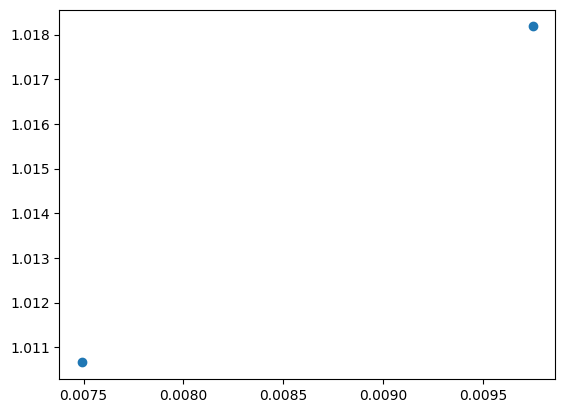

In [42]:
plt.scatter(a["std"],a["cr"])
plt.show()

In [43]:
valuation_method = "coefficient_of_variance"
ascending = False

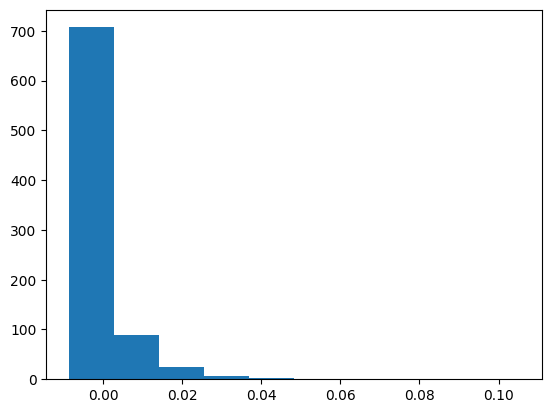

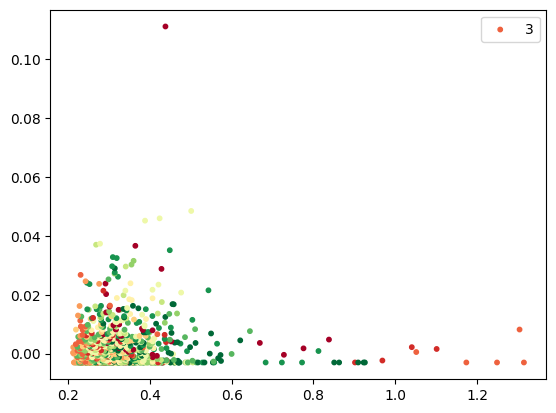

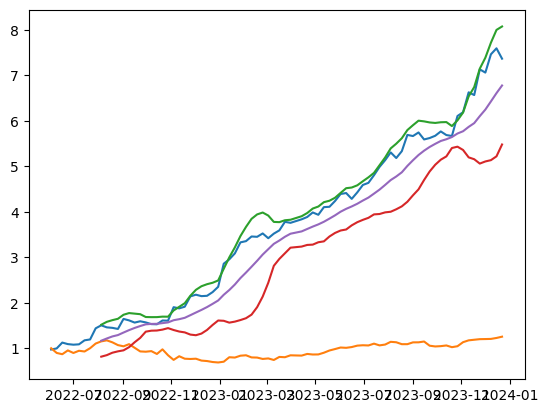

In [58]:
try:
    iteration_trades = trades.copy().sort_values(valuation_method,ascending=ascending).groupby(["date"]).nth([i for i in range(positions)])
    portfolio = iteration_trades[["date","hedged_return"]].groupby("date").sum().reset_index()
    portfolio.sort_values("date",inplace=True)
    portfolio = portfolio[(portfolio["date"]>portfolio["date"].min()) & (portfolio["date"]<portfolio["date"].max())]
    portfolio = portfolio.merge(benchmark,on="date")
    portfolio["benchmark_cumulative_return"] = (portfolio["adjclose"] - portfolio["adjclose"].iloc[0]) / portfolio["adjclose"].iloc[0] + 1
    portfolio["hedged_return"] = portfolio["hedged_return"] + 1
    portfolio["cumulative_return"] = portfolio["hedged_return"].cumprod()
    portfolio["mid"] = portfolio["cumulative_return"].rolling(10).mean()
    portfolio["upper"] = portfolio["cumulative_return"].rolling(10).mean() +  2 * portfolio["cumulative_return"].rolling(10).std() 
    portfolio["lower"] = portfolio["cumulative_return"].rolling(10).mean() -  2 * portfolio["cumulative_return"].rolling(10).std() 
    recommendations = iteration_trades[["date","sell_date","ticker","adjclose",valuation_method]].sort_values(["date"]).tail(positions)
    plt.hist(iteration_trades["hedged_return"],bins=10,align="left")
    plt.show()
    scatter = iteration_trades.sort_values("hedged_return")
    plt.scatter(scatter["coefficient_of_variance"].values,scatter["hedged_return"].values,c=scatter["month"],cmap="RdYlGn",s=10)
    plt.legend(list(iteration_trades["month"].unique()))
    plt.show()
    plt.plot(portfolio["date"].values,portfolio["cumulative_return"].values)
    plt.plot(portfolio["date"].values,portfolio["benchmark_cumulative_return"].values)
    plt.plot(portfolio["date"].values,portfolio["upper"].values)
    plt.plot(portfolio["date"].values,portfolio["lower"].values)
    plt.plot(portfolio["date"].values,portfolio["mid"].values)
    plt.show()
except Exception as e:
    print(str(e))

In [59]:
portfolio

,date,hedged_return,adjclose,benchmark_cumulative_return,cumulative_return,mid,upper,lower
0,2022-06-03 04:00:00+00:00,0.971076,122.35,1.000000,0.971076,NaN,NaN,NaN
1,2022-06-10 04:00:00+00:00,1.025718,109.65,0.896199,0.996050,NaN,NaN,NaN
2,2022-06-17 04:00:00+00:00,1.128643,106.22,0.868165,1.124185,NaN,NaN,NaN
3,2022-06-24 04:00:00+00:00,0.970188,116.46,0.951859,1.090671,NaN,NaN,NaN
4,2022-07-01 04:00:00+00:00,0.988159,109.56,0.895464,1.077756,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
76,2023-11-24 05:00:00+00:00,1.086069,146.74,1.199346,7.133416,6.104698,7.148368,5.061028
77,2023-12-01 05:00:00+00:00,0.989999,147.03,1.201716,7.062078,6.248632,7.389377,5.107887
78,2023-12-08 05:00:00+00:00,1.056994,147.42,1.204904,7.464573,6.427823,7.719439,5.136206
79,2023-12-15 05:00:00+00:00,1.017608,149.97,1.225746,7.596010,6.610629,8.000858,5.220401


In [60]:
iteration_trades.sort_values("return",ascending=False).head(10)

,date,week,month,weekday,ticker,adjclose,coefficient_of_variance,buy_price,buy_date,sell_price,sell_date,return,weight,hedged_return,year,quarter
330945,2023-01-06 05:00:00+00:00,1,1,4,SHC,8.46,0.438004,8.64,2023-01-09 05:00:00+00:00,18.23,2023-01-13 05:00:00+00:00,0.110995,0.1,0.110995,2023,1
90757,2022-07-29 04:00:00+00:00,30,7,4,COIN,62.96,0.500970,62.70,2022-08-01 04:00:00+00:00,93.05,2022-08-05 04:00:00+00:00,0.048405,0.1,0.048405,2022,3
224417,2022-07-29 04:00:00+00:00,30,7,4,LYFT,13.86,0.423782,13.90,2022-08-01 04:00:00+00:00,20.28,2022-08-05 04:00:00+00:00,0.045899,0.1,0.045899,2022,3
87130,2022-07-29 04:00:00+00:00,30,7,4,NET,50.32,0.388070,51.16,2022-08-01 04:00:00+00:00,74.24,2022-08-05 04:00:00+00:00,0.045113,0.1,0.045113,2022,3
374757,2023-07-28 04:00:00+00:00,30,7,4,VRT,25.95,0.277980,26.01,2023-07-31 04:00:00+00:00,35.71,2023-08-04 04:00:00+00:00,0.037293,0.1,0.037293,2023,3
29316,2023-08-04 04:00:00+00:00,31,8,4,APLS,24.53,0.268374,23.65,2023-08-07 04:00:00+00:00,32.39,2023-08-11 04:00:00+00:00,0.036956,0.1,0.036956,2023,3
6201,2023-01-06 05:00:00+00:00,1,1,4,AFRM,9.06,0.364383,9.43,2023-01-09 05:00:00+00:00,12.88,2023-01-13 05:00:00+00:00,0.036585,0.1,0.036585,2023,1
18249,2022-11-04 04:00:00+00:00,44,11,4,AMC,56.50,0.448585,53.30,2022-11-07 05:00:00+00:00,72.00,2022-11-11 04:00:00+00:00,0.035084,0.1,0.035084,2022,4
287240,2023-11-24 05:00:00+00:00,47,11,4,PLUG,3.47,0.309283,3.42,2023-11-27 05:00:00+00:00,4.54,2023-12-01 05:00:00+00:00,0.032749,0.1,0.032749,2023,4
266801,2022-11-04 04:00:00+00:00,44,11,4,OLPX,4.38,0.318825,4.38,2022-11-07 05:00:00+00:00,5.80,2022-11-11 04:00:00+00:00,0.032420,0.1,0.032420,2022,4


In [61]:
recommendations

,date,sell_date,ticker,adjclose,coefficient_of_variance
282403,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,WOOF,3.16,0.282662
76203,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,CHPT,2.34,0.471108
262253,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,NVCR,14.93,0.350426
175133,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,HTZ,10.39,0.278802
156837,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,GPS,20.91,0.308902
18537,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,AMC,6.12,0.850755
287264,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,PLUG,4.50,0.290989
6447,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,AFRM,49.14,0.412975
252581,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,VYX,16.91,0.286008
91114,2023-12-29 05:00:00+00:00,2024-01-05 05:00:00+00:00,COIN,173.92,0.328155


In [14]:
db.connect()
# db.drop('portfolio')
# db.drop('trades')
db.drop('recommendations')
# db.store("portfolio",portfolio)
# db.store("trades",iteration_trades)
db.store("recommendations",recommendations)
db.disconnect()